In [1]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr
import numpyro
import numpyro.distributions as dist

from model import (
    MiniGPJax,
    # kernel / mean / likelihood classes
    RBF, Matern32, GaussianLikelihood, ZeroMean, GPParams, Standardizer,
    # state (de)serializers defined in your file
    _kernel_to_state, _kernel_from_state,
    _lik_to_state, _lik_from_state,
    _zeromean_to_state, _zeromean_from_state,
    _gpparams_to_state, _gpparams_from_state,
    _std_to_state, _std_from_state,
)
from model import MiniGPJax, _register_all_serializers_once
_register_all_serializers_once()

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_CSV = "Completed_Train_set_3.csv" #Completed_train_set_10_30_25.csv#"Train_Set_2.csv"
TEST_CSV  = "Completed_Test_set_3.csv"#"Test_Set_2.csv"
CKPT_DIR  = "ckpts/gp_run_006"
dim = 5
gp = MiniGPJax(
    dim=dim,
    kernel="rbf",            # or "matern32" I dont have the others
    fixed_noise=None,        # consider None to learn noise for better generalization
    standardize_x=True,
    standardize_y=True,
    log_y=True,              # ensures: log -> standardize (train stats) -> fit
    jitter=1e-6,
)
gp.load(TRAIN_CSV, TEST_CSV)
gp.fit(lbfgs_max_iter=30, lbfgs_tol=1e-7, num_restarts=2, seed=200)

#

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1767119935.408170 11497935 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767119935.430067 11497935 service.cc:145] XLA service 0x600003670000 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767119935.430227 11497935 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767119935.431888 11497935 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767119935.431914 11497935 mps_client.cc:384] XLA backend will use up to 26800209920 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Max
[ok] Loaded train: X=(1024, 5), y=(1024,) (log→std)
[ok] Loaded test:  X=(256, 5), y=(256,) (log→std)
[restart 0] nLML = -1756.754517
[restart 1] nLML = -1756.754517
[ok] Best nLML = -1756.754517
[fit] amp=2.356 | noise_var=2.588e-05 | ell=[5.136 1.915 9.435 0.417 3.39 ]
[fit] train RMSE(z)=0.0040 | R²(z)=1.0000  (z = standardized)


In [3]:
gp.evaluate_and_plot(outdir="12_14_2025")  # defaults to "log" when log_y=True


[eval:log] RMSE(log)=0.036881 | MAE(log)=0.013797 | R²(log)=0.998990


{'rmse_log': 0.03688124939799309,
 'mae_log': 0.013796549290418625,
 'r2_log': 0.9989898231403537}

In [4]:
_register_all_serializers_once()
gp.save_checkpoint(CKPT_DIR)

[save] Wrote checkpoint to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_006


In [5]:
CKPT_DIR = "ckpts/gp_run_006"
TRAIN_CSV = "Completed_Train_set_3.csv"
_register_all_serializers_once()
gp_loaded = MiniGPJax.ready_from_checkpoint(CKPT_DIR, train_csv=TRAIN_CSV, rebuild=True)

[load] Loaded config+params from: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_006
[posterior] Rebuilt training posterior.


# Sanity check

In [201]:
x_single = np.array([[0.6,5500,0.39,7.,4.45E-07]], dtype=np.float32)  # shape (1, 5)

mu, std = gp_loaded.predict(x_single)
print(mu/1e7, std/1e7)

[0.20595287] [0.00180454]


In [7]:
import jax
import jax.numpy as jnp

# cache these once (they are jnp arrays)
x_mean = gp_loaded.std.x_mean   # shape (dim,)
x_std  = gp_loaded.std.x_std    # shape (dim,)

def _gp_predict_mean_from_Xn_std(Xn_std: jnp.ndarray) -> jnp.ndarray:
    """
    Xn_std: (N, dim) already-standardized inputs (same space GP was trained in).
    Returns: (N,) mean prediction in original y units (with lognormal correction if log_y=True).
    """
    # Posterior in z-space (standardized log(y) if log_y=True)
    mean_z, std_z = gp_loaded.posterior.predict(Xn_std, include_noise=False)

    # Undo y-standardization (still log-space if log_y=True)
    mean_z_log, std_z_log = gp_loaded.std.inverse_y(mean_z, std_z)

    return mean_z_log

def gp_single_z(z1, z2, z3, z4, flow_raw):
    """
    z1..z4 are standardized coordinates for x1..x4 (what NUTS samples).
    flow_raw is in original physical units (whatever you used in training CSV as x5).
    """
    # Standardize the flow dimension to match GP training space
    z5 = (flow_raw - x_mean[4]) / x_std[4]

    Xn_std = jnp.stack([z1, z2, z3, z4, z5])         # (dim,)
    return _gp_predict_mean_from_Xn_std(Xn_std[None, :])[0]

# vectorize over flow values
gp_flow_maps = jax.vmap(gp_single_z, (None, None, None, None, 0))


In [228]:
# physical inputs
x_phys = jnp.array([0.4, 1000.0, 3., 0.01])

# standardize using GP training statistics
z_phys = (x_phys - gp_loaded.std.x_mean[:4]) / gp_loaded.std.x_std[:4]

z1, z2, z3, z4 = z_phys

flows = jnp.array([2.4e-7, 3.45e-7, 8.1e-7])

prins = gp_flow_maps(z1, z2, z3, z4, flows)# / 6894.76
print(prins)


[14.00054  14.198644 14.707902]


## Lets check somethign

In [9]:
df = pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Pressure")               
df.head()

subset = df.iloc[1:, 2:6]
# Make the first row the header

new_header = subset.iloc[0]   # get the first row
subset = subset[1:]           # take the data after the header row
subset.columns = new_header   # set header
subset = subset.reset_index(drop=True)  # clean index
print(subset.head())

pressure = subset['Pump Pressure(PSI)'].values[1:]
pressure_times = subset['Time(s)'].values[1:]

1   Time(s) Extruder Pressure (PSI) Pump Pressure(PSI) Temperature(C)
0         0               687.94829         332.927429     279.594642
1  0.060966              721.002479         305.609107     279.594642
2  0.108939              747.514903         285.115698     279.594642
3  0.154912               767.74587         270.662268     279.594642
4  0.200885              781.886558          261.56303     279.594642


(array([1.000e+00, 1.000e+00, 1.119e+03, 7.230e+02, 1.200e+01, 7.800e+01,
        1.363e+03, 4.850e+02, 1.000e+00, 1.000e+00]),
 array([-2.11480363, -1.53596184, -0.95712005, -0.37827827,  0.20056352,
         0.77940531,  1.35824709,  1.93708888,  2.51593067,  3.09477245,
         3.67361424]),
 <BarContainer object of 10 artists>)

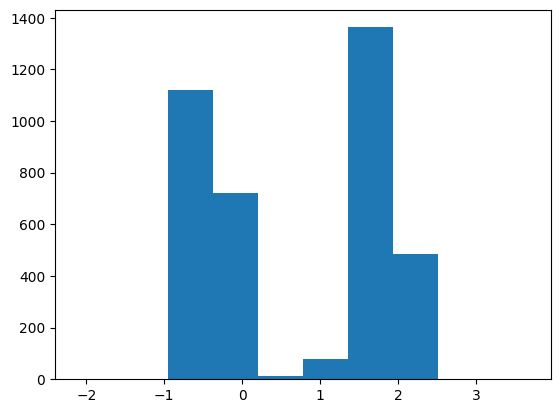

In [10]:
df= pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Position")
df.head()
columns_to_drop = [0, 1,7, 9, 10, 11, 12]

df.drop(df.columns[columns_to_drop], axis=1, inplace=True)


subset = df.iloc[1:, :]
new_header = subset.iloc[0]
subset.columns = new_header
subset = subset.reset_index(drop=True)  # clean index
subset.head()

# xreate all the ararys 

time = subset['Time(seconds)'].values[1:]
x_locs = subset['x(mm)'].values[1:]
y_locs = subset['y(mm)'].values[1:]
z_locs = subset['z(mm)'].values[1:]
speeds = subset['Speed (mm/s)'].values[1:]
flow_rates = subset['Flowrate[m^3/s]'].values[1:]

extract_flow = 2.91582835522733e-07
mask = (flow_rates > 0.96 * extract_flow) & (flow_rates < 1.04 * extract_flow)
plt.hist((flow_rates[np.argwhere(mask)] - extract_flow)/extract_flow * 100)

In [11]:
# cleaned version of my code above from CHATGPT

def middle50_slice(n: int):
    i0 = int(0.25 * n)
    i1 = max(int(0.75 * n), i0 + 1)
    return i0, i1
    
def steady_mean_of_segment(times: np.ndarray, pressures: np.ndarray):
    """mean and standard error from the middle 50% of the time segment."""
    times = np.asarray(times)
    pressures = np.asarray(pressures, dtype=float)

    i0, i1 = middle50_slice(len(pressures))
    x = pressures[i0:i1]

    m = np.mean(x)
    s = np.std(x, ddof=1) if x.size > 1 else np.nan
    se = s / np.sqrt(x.size) if x.size > 1 else np.nan
    return m, se
    
def extract_layer_data(layer: int,
                       layer_height: float,
                       z_locs: np.ndarray,
                       time: np.ndarray,
                       speeds: np.ndarray,
                       flow_rates: np.ndarray,
                       pressure_times: np.ndarray,
                       pressure: np.ndarray,
                       extract_flow: float,
                       flow_sensor_error_percentage: float = 1.0):
    """
    Extracts steady-state flow and corresponding pressure data for a given layer.

    Parameters
    ----------
    layer : int
        Layer number (1-indexed).
    layer_height : float
        Height of one layer in mm.
    z_locs : np.ndarray
        Array of z-locations (same length as `time` and `flow_rates`).
    time : np.ndarray
        Array of timestamps for flow measurements.
    speeds : np.ndarray
        Array of speeds corresponding to each time.
    flow_rates : np.ndarray
        Array of flow rate measurements.
    pressure_times : np.ndarray
        Array of timestamps for pressure measurements.
    pressure : np.ndarray
        Array of pressure values.
    extract_flow : float
        Expected flow rate to extract steady-state region.
    flow_sensor_error_percentage : float, optional
        Allowed sensor error in %, default 5%.

    Returns
    -------
    dict
        Dictionary containing:
        - 'times_speeds': np.ndarray of times during steady-state
        - 'flow_rates_ss': np.ndarray of steady-state flow rates
        - 'pressure_times_ss': np.ndarray of matching pressure times
        - 'pressures_ss': np.ndarray of matching pressure values
        - 'mask_flow_rates': np.ndarray of indices of steady-state flow points
    """

    # Compute allowed flow rate range
    extract_flow_min = extract_flow * (1 - 0.01 * flow_sensor_error_percentage)
    extract_flow_max = extract_flow * (1 + 0.01 * flow_sensor_error_percentage)

    # Extract layer
    mask_layer = np.argwhere(
        (z_locs >= layer_height * (layer - 1)) & (z_locs < layer_height * layer)
    ).flatten()
    times_layer = time[mask_layer]
    speeds_layer = speeds[mask_layer]
    flow_rates_layer = flow_rates[mask_layer]

    # Steady-state flow mask
    mask_flow = np.argwhere(
        (flow_rates_layer >= extract_flow_min) & (flow_rates_layer <= extract_flow_max)
    ).flatten()
    times_speeds = times_layer[mask_flow]
    flow_rates_ss = flow_rates_layer[mask_flow]

    # Matching pressure segment
    if len(times_speeds) > 0:
        time_range = np.array([np.min(times_speeds), np.max(times_speeds)])
        mask_pressure = np.argwhere(
            (pressure_times >= time_range[0]) & (pressure_times <= time_range[1])
        ).flatten()
        pressure_times_ss = pressure_times[mask_pressure]
        pressures_ss = pressure[mask_pressure]
    else:
        pressure_times_ss = np.array([])
        pressures_ss = np.array([])

    return {
        "times_speeds": times_speeds,
        "flow_rates_ss": flow_rates_ss,
        "pressure_times_ss": pressure_times_ss,
        "pressures_ss": pressures_ss,
        "mask_flow_rates": mask_flow,
    }

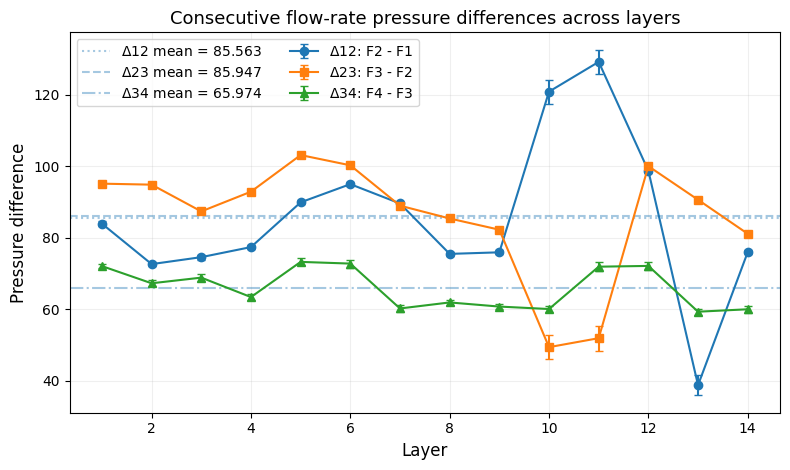

\Delta 12: mean=85.5635, std_across_layers=21.9971, n=14, median_SE=0.6142
\Delta 23: mean=85.9465, std_across_layers=16.3597, n=14, median_SE=0.6397
\Delta 34: mean=65.9743, std_across_layers=5.6731, n=14, median_SE=0.9143


In [12]:
flows = np.array([
    2.91582835522733e-07,
    4.84503201019647e-07,
    6.87113630536953e-07,
    8.89724060054260e-07,
], dtype=np.float32)

# ---------- collect per-layer steady means ----------
n_layers = 14
means = np.full((n_layers, 4), np.nan)
sems  = np.full((n_layers, 4), np.nan)

# NEW: store per-layer average measured flow for each of the 4 flow setpoints
flow_means = np.full((n_layers, 4), np.nan)
flow_sems  = np.full((n_layers, 4), np.nan)

def pick_first_key(d: dict, candidates):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return None

for layer in range(1, n_layers + 1):
    for k, flow in enumerate(flows):
        res = extract_layer_data(
            layer=layer,
            layer_height=1.5,
            z_locs=z_locs,
            time=time,
            speeds=speeds,
            flow_rates=flow_rates,
            pressure_times=pressure_times,
            pressure=pressure,
            extract_flow=flow,
            flow_sensor_error_percentage=4.0,
        )

        # ----- pressure steady-state stats (existing) -----
        pt = res["pressure_times_ss"]
        pv = res["pressures_ss"]
        m, se = steady_mean_of_segment(pt, pv)
        means[layer-1, k] = m
        sems[layer-1, k]  = se

        # ----- flow steady-state stats (NEW) -----
        # Try to read steady-state flow directly if provided by extract_layer_data
        ft = pick_first_key(res, ["flow_times_ss", "flowrate_times_ss", "flow_rate_times_ss"]) or pt
        fv = pick_first_key(res, ["flow_rates_ss", "flowrate_ss", "flows_ss", "flow_ss"])

        if fv is None:
            # Fallback: estimate from the raw flow_rates around the commanded flow ± sensor error,
            # within the same time indices used for pressure steady-state, if available.
            # Try to get the boolean mask / indices for the steady window:
            mask_ss = pick_first_key(res, ["mask_ss", "steady_mask", "ss_mask"])
            if mask_ss is not None and mask_ss.shape == flow_rates.shape:
                cand = flow_rates[mask_ss]
            else:
                # last-resort: just band around the setpoint across all samples
                band = 0.04 * flow
                mask = (flow_rates > (flow - band)) & (flow_rates < (flow + band))
                cand = flow_rates[mask]

            if cand.size > 1:
                fm, fse = float(np.mean(cand)), float(np.std(cand, ddof=1) / np.sqrt(cand.size))
            elif cand.size == 1:
                fm, fse = float(cand[0]), np.nan
            else:
                fm, fse = np.nan, np.nan
        else:
            # We have steady-state flow vector fv (and possibly its times ft)
            fm, fse = steady_mean_of_segment(ft, fv)

        flow_means[layer-1, k] = fm
        flow_sems[layer-1, k]  = fse

# ---------- consecutive differences & error propagation (unchanged) ----------
d12 = means[:, 1] - means[:, 0]
d23 = means[:, 2] - means[:, 1]
d34 = means[:, 3] - means[:, 2]

sd12 = np.sqrt(sems[:, 1]**2 + sems[:, 0]**2)
sd23 = np.sqrt(sems[:, 2]**2 + sems[:, 1]**2)
sd34 = np.sqrt(sems[:, 3]**2 + sems[:, 2]**2)

layers = np.arange(1, n_layers + 1)

# ---------- plot (unchanged) ----------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(layers, d12, yerr=sd12, fmt='o-', capsize=3, label=r'$\Delta 12$: F2 - F1')
ax.errorbar(layers, d23, yerr=sd23, fmt='s-', capsize=3, label=r'$\Delta 23$: F3 - F2')
ax.errorbar(layers, d34, yerr=sd34, fmt='^-', capsize=3, label=r'$\Delta 34$: F4 - F3')

for d, name, ls in [(d12, r'$\Delta 12$ mean', ':'), (d23, r'$\Delta 23$ mean', '--'), (d34, r'$\Delta 34$ mean', '-.')]:
    mu = np.nanmean(d)
    ax.axhline(mu, linestyle=ls, alpha=0.4, label=fr'{name} = {mu:.3f}')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Pressure difference', fontsize=12)
ax.set_title('Consecutive flow-rate pressure differences across layers', fontsize=13)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- quick numeric summary (unchanged) ----------
def summarize(name, d, sd):
    valid = np.isfinite(d)
    mu = np.nanmean(d)
    sdv = np.nanstd(d, ddof=1)
    print(f"{name}: mean={mu:.4f}, std_across_layers={sdv:.4f}, "
          f"n={valid.sum()}, median_SE={np.nanmedian(sd):.4f}")

summarize(r"\Delta 12", d12, sd12)
summarize(r"\Delta 23", d23, sd23)
summarize(r"\Delta 34", d34, sd34)

# ---------- NEW: per-layer average flow arrays ----------
f1, f2, f3, f4 = (flow_means[:, 0], flow_means[:, 1], flow_means[:, 2], flow_means[:, 3])

In [13]:
f1, f2, f3, f4 

(array([2.93627198e-07, 2.93676909e-07, 2.93644968e-07, 2.93645849e-07,
        2.93646324e-07, 2.93646379e-07, 2.93645408e-07, 2.93645320e-07,
        2.93646172e-07, 2.93650315e-07, 2.93677263e-07, 2.93645792e-07,
        2.93637702e-07, 2.93632100e-07]),
 array([4.89300225e-07, 4.89446144e-07, 4.89321181e-07, 4.89426290e-07,
        4.89327910e-07, 4.89422652e-07, 4.89328649e-07, 4.89376159e-07,
        4.89315934e-07, 4.89393384e-07, 4.89367970e-07, 4.89331961e-07,
        4.89418655e-07, 4.89329390e-07]),
 array([6.85093665e-07, 6.84855238e-07, 6.85089509e-07, 6.84826414e-07,
        6.85088984e-07, 6.84855173e-07, 6.84861604e-07, 6.84850090e-07,
        6.84847226e-07, 6.85055299e-07, 6.85060445e-07, 6.84852056e-07,
        6.85092417e-07, 6.84854963e-07]),
 array([8.81212682e-07, 8.80380295e-07, 8.81222209e-07, 8.80408842e-07,
        8.81259403e-07, 8.80749495e-07, 8.81141543e-07, 8.80747231e-07,
        8.81508628e-07, 8.80764489e-07, 8.81556670e-07, 8.80807990e-07,
        8.

In [14]:
import numpy as np
import pandas as pd

PSI_TO_PA = 6894.76
PA_TO_PSI = 1.0 / PSI_TO_PA

# -----------------------------
# AFTER your per-layer loop fills:
#   means, sems  (pressures in PSI, since 'pressure' is in PSI)
#   flow_means, flow_sems (flows)
# -----------------------------

# Absolute pressures per flow setpoint (PSI)
p1_psi = means[:, 0]
p2_psi = means[:, 1]
p3_psi = means[:, 2]
p4_psi = means[:, 3]

# Standard errors (PSI)
sp1_psi = sems[:, 0]
sp2_psi = sems[:, 1]
sp3_psi = sems[:, 2]
sp4_psi = sems[:, 3]

# Absolute pressures in Pa
p1_pa = p1_psi * PSI_TO_PA
p2_pa = p2_psi * PSI_TO_PA
p3_pa = p3_psi * PSI_TO_PA
p4_pa = p4_psi * PSI_TO_PA

# Standard errors in Pa
sp1_pa = sp1_psi * PSI_TO_PA
sp2_pa = sp2_psi * PSI_TO_PA
sp3_pa = sp3_psi * PSI_TO_PA
sp4_pa = sp4_psi * PSI_TO_PA

# -----------------------------
# Differences (PSI) — same as your existing code
# -----------------------------
d12_psi = p2_psi - p1_psi
d23_psi = p3_psi - p2_psi
d34_psi = p4_psi - p3_psi

sd12_psi = np.sqrt(sp2_psi**2 + sp1_psi**2)
sd23_psi = np.sqrt(sp3_psi**2 + sp2_psi**2)
sd34_psi = np.sqrt(sp4_psi**2 + sp3_psi**2)

# Differences in Pa
d12_pa = d12_psi * PSI_TO_PA
d23_pa = d23_psi * PSI_TO_PA
d34_pa = d34_psi * PSI_TO_PA

sd12_pa = sd12_psi * PSI_TO_PA
sd23_pa = sd23_psi * PSI_TO_PA
sd34_pa = sd34_psi * PSI_TO_PA

# -----------------------------
# Build a clean dataframe with everything
# -----------------------------
layers = np.arange(1, n_layers + 1)

out = pd.DataFrame({
    "layer": layers,

    # flows (what you already computed)
    "flow1_mean_m3s": flow_means[:, 0],
    "flow2_mean_m3s": flow_means[:, 1],
    "flow3_mean_m3s": flow_means[:, 2],
    "flow4_mean_m3s": flow_means[:, 3],
    "flow1_se_m3s": flow_sems[:, 0],
    "flow2_se_m3s": flow_sems[:, 1],
    "flow3_se_m3s": flow_sems[:, 2],
    "flow4_se_m3s": flow_sems[:, 3],

    # absolute pressures (psi)
    "p1_psi": p1_psi, "p1_se_psi": sp1_psi,
    "p2_psi": p2_psi, "p2_se_psi": sp2_psi,
    "p3_psi": p3_psi, "p3_se_psi": sp3_psi,
    "p4_psi": p4_psi, "p4_se_psi": sp4_psi,

    # absolute pressures (Pa)
    "p1_pa": p1_pa, "p1_se_pa": sp1_pa,
    "p2_pa": p2_pa, "p2_se_pa": sp2_pa,
    "p3_pa": p3_pa, "p3_se_pa": sp3_pa,
    "p4_pa": p4_pa, "p4_se_pa": sp4_pa,

    # differences (psi)
    "d12_psi": d12_psi, "d12_se_psi": sd12_psi,
    "d23_psi": d23_psi, "d23_se_psi": sd23_psi,
    "d34_psi": d34_psi, "d34_se_psi": sd34_psi,

    # differences (Pa)
    "d12_pa": d12_pa, "d12_se_pa": sd12_pa,
    "d23_pa": d23_pa, "d23_se_pa": sd23_pa,
    "d34_pa": d34_pa, "d34_se_pa": sd34_pa,
})

# -----------------------------
# Save to disk
# -----------------------------
out_path = "processed_layer_pressures_and_differences.csv"
out.to_csv(out_path, index=False)
print(f"[ok] saved: {out_path}")
print(out.head())


[ok] saved: processed_layer_pressures_and_differences.csv
   layer  flow1_mean_m3s  flow2_mean_m3s  flow3_mean_m3s  flow4_mean_m3s  \
0      1    2.936272e-07    4.893002e-07    6.850937e-07    8.812127e-07   
1      2    2.936769e-07    4.894461e-07    6.848552e-07    8.803803e-07   
2      3    2.936450e-07    4.893212e-07    6.850895e-07    8.812222e-07   
3      4    2.936458e-07    4.894263e-07    6.848264e-07    8.804088e-07   
4      5    2.936463e-07    4.893279e-07    6.850890e-07    8.812594e-07   

   flow1_se_m3s  flow2_se_m3s  flow3_se_m3s  flow4_se_m3s      p1_psi  ...  \
0  2.539022e-10  5.332308e-10  8.972141e-10  2.000338e-09  229.162703  ...   
1  2.651728e-10  5.341661e-10  8.989805e-10  1.924441e-09  221.126100  ...   
2  2.531826e-10  4.843015e-10  8.919628e-10  1.915984e-09  205.536861  ...   
3  2.653207e-10  5.606945e-10  8.947217e-10  1.935696e-09  192.631382  ...   
4  2.652368e-10  5.542144e-10  9.206466e-10  1.977344e-09  202.656297  ...   

      d23_psi  d

## Collect vectors

In [15]:
F = jnp.concatenate([f1[:, None],f2[:, None],f3[:, None],f4[:, None]], axis =1)

P_pa = jnp.concatenate([p1_pa[:, None], p2_pa[:, None], p3_pa[:, None], p4_pa[:, None]], axis=1)

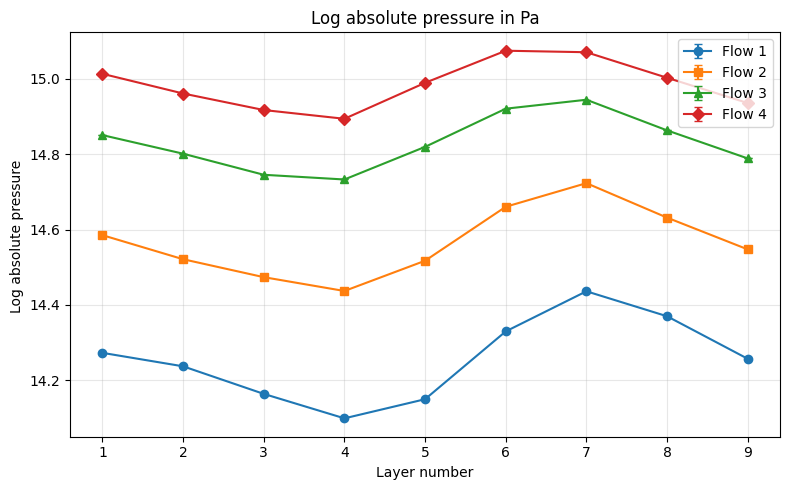

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(layers[:9], np.log(p1_pa)[:9], yerr=0., fmt="o-", capsize=3, label="Flow 1")
plt.errorbar(layers[:9], np.log(p2_pa)[:9], yerr=0., fmt="s-", capsize=3, label="Flow 2")
plt.errorbar(layers[:9], np.log(p3_pa)[:9], yerr=0., fmt="^-", capsize=3, label="Flow 3")
plt.errorbar(layers[:9], np.log(p4_pa)[:9], yerr=0., fmt="D-", capsize=3, label="Flow 4")

plt.xlabel("Layer number")
plt.ylabel("Log absolute pressure ")
plt.title("Log absolute pressure in Pa")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


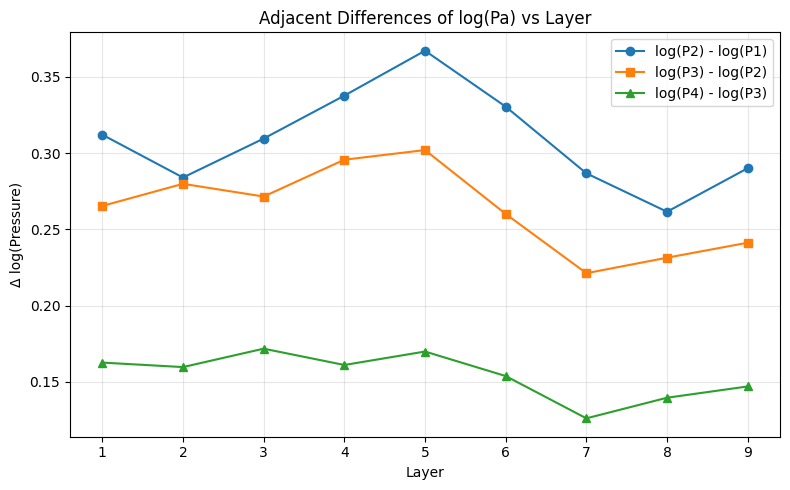

In [309]:
import numpy as np
import matplotlib.pyplot as plt

# Stack pressures into (N, 4)
P = np.vstack([p1_pa, p2_pa, p3_pa, p4_pa]).T

# Log pressures
logP = np.log(P)

# Adjacent log differences
d21 = logP[:, 1] - logP[:, 0]
d32 = logP[:, 2] - logP[:, 1]
d43 = logP[:, 3] - logP[:, 2]

plt.figure(figsize=(8, 5))

plt.plot(layers[:9], d21[:9], "o-", label="log(P2) - log(P1)")
plt.plot(layers[:9], d32[:9], "s-", label="log(P3) - log(P2)")
plt.plot(layers[:9], d43[:9], "^-", label="log(P4) - log(P3)")

plt.xlabel("Layer")
plt.ylabel("Δ log(Pressure)")
plt.title("Adjacent Differences of log(Pa) vs Layer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [164]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp

def model_calibrate_abslog_multiflow_constbias_perflow(F, y_log_pa, L=9):
    """
    F        : (N, K) flows   (K=4)
    y_log_pa : (N, K) observed log(Pa)
    """

    N, K = F.shape

    # -----------------------
    # Calibrate GP inputs in standardized space (shared)
    # -----------------------
    z1 = numpyro.sample("z1", dist.Normal(0.0, 0.7))
    z2 = numpyro.sample("z2", dist.Normal(0.0, 0.7))
    z3 = numpyro.sample("z3", dist.Normal(0.0, 0.7))
    z4 = numpyro.sample("z4", dist.Normal(-0.5, 0.2))

    # -----------------------
    # GP predictions: log(Pa) for each flow column
    # -----------------------
    MU = jnp.stack(
        [gp_flow_maps(z1, z2, z3, z4, F[:, j]) for j in range(K)],
        axis=1
    )  # (N, K)

    # -----------------------
    # Constant bias per flow column
    # -----------------------
    #b = numpyro.sample("b", dist.Normal(0.0, 0.02).expand([K]))  # (K,)
    MU_biased = MU #+ b[None, :]                                # (N, K)

    # -----------------------
    # Noise PER FLOW (shared across layers)
    # -----------------------
    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(0.3).expand([K])   # (K,)
    )

    numpyro.sample(
        "y",
        dist.Normal(MU_biased, sigma),     # broadcasts (K,) -> (N,K)
        obs=y_log_pa
    )


In [212]:
# def model_calibrate_abslog_multiflow_constbias_perflow(F, y_log_pa, L=9):
#     N, K = F.shape

#     z1 = numpyro.sample("z1", dist.Normal(0.0, 0.7))
#     z2 = numpyro.sample("z2", dist.Normal(0.0, 0.7))
#     z3 = numpyro.sample("z3", dist.Normal(0.0, 0.7))

#     # --- prior in physical space (positive) ---
#     log_x4 = numpyro.sample("log_x4_phys", dist.Uniform(jnp.log(1e-2), jnp.log(12.0)))
#     x4_phys = jnp.exp(log_x4)
#     numpyro.deterministic("x4_phys", x4_phys)

#     # --- map physical -> GP input scale -> standardized z4 ---
#     # If your GP was trained with x4_phys directly (then standardized):
#     x4_gp = x4_phys
#     z4 = (x4_gp - x_mean[3]) / x_std[3]   # use your gp_loaded.std stats
#     numpyro.deterministic("z4", z4)

#     MU = jnp.stack([gp_flow_maps(z1, z2, z3, z4, F[:, j]) for j in range(K)], axis=1)

#     sigma = numpyro.sample("sigma", dist.HalfNormal(0.3).expand([K]))
#     numpyro.sample("y", dist.Normal(MU, sigma), obs=y_log_pa)

In [213]:
L=9
layer_idx = jnp.arange(1, 10)   # shape (9,)



In [214]:
from numpyro.infer import MCMC, NUTS, init_to_median
import jax.random as jr
import jax.numpy as jnp

def run_nuts_calibration_abslog_constantbias(
    F, P_pa, layer_idx,
    seed=111, warmup=300, samples=5000, chains=2,
    target_accept=0.75, max_tree_depth=10,
):
    # Convert absolute pressure in Pa -> log(Pa)
    y_log_pa = jnp.log(P_pa)

    kernel = NUTS(
        model_calibrate_abslog_multiflow_constbias_perflow,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
        dense_mass=False,
    )

    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",
        progress_bar=True,
    )

    key = jr.PRNGKey(seed)

    # order must match model signature: (F, y_log_pa, layer_idx, L=9)
    mcmc.run(key, F, y_log_pa, layer_idx)

    mcmc.print_summary()
    return mcmc

# Call it
mcmc = run_nuts_calibration_abslog_constantbias(F[:L, :], P_pa[:L, :], layer_idx)
samples = mcmc.get_samples()


#run_nuts_calibration_abslog_sinebias

sample: 100%|█████████████████████████████████████████████████████████| 5300/5300 [04:31<00:00, 19.53it/s, 63 steps of size 3.33e-02. acc. prob=0.73]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
  log_x4_phys      1.51      0.92      1.76      0.38      2.48    577.53      1.01
     sigma[0]      0.13      0.04      0.12      0.07      0.17   4422.32      1.00
     sigma[1]      0.11      0.03      0.10      0.06      0.15   5270.19      1.00
     sigma[2]      0.08      0.02      0.08      0.05      0.12   4049.43      1.00
     sigma[3]      0.07      0.02      0.07      0.04      0.11   4820.17      1.00
           z1      0.10      0.26      0.12     -0.29      0.53   1188.42      1.00
           z2     -0.60      0.47     -0.60     -1.39      0.15   1404.69      1.01
           z3      0.03      0.71      0.02     -1.11      1.20   4507.30      1.00

Number of divergences: 202


In [167]:
print("F", F[:L,:].shape)
print("P_pa", P_pa[:L,:].shape)
print("layer_idx", layer_idx[:L].shape)
print("y_log_pa", jnp.log(P_pa[:L,:]).shape)

F (9, 4)
P_pa (9, 4)
layer_idx (9,)
y_log_pa (9, 4)


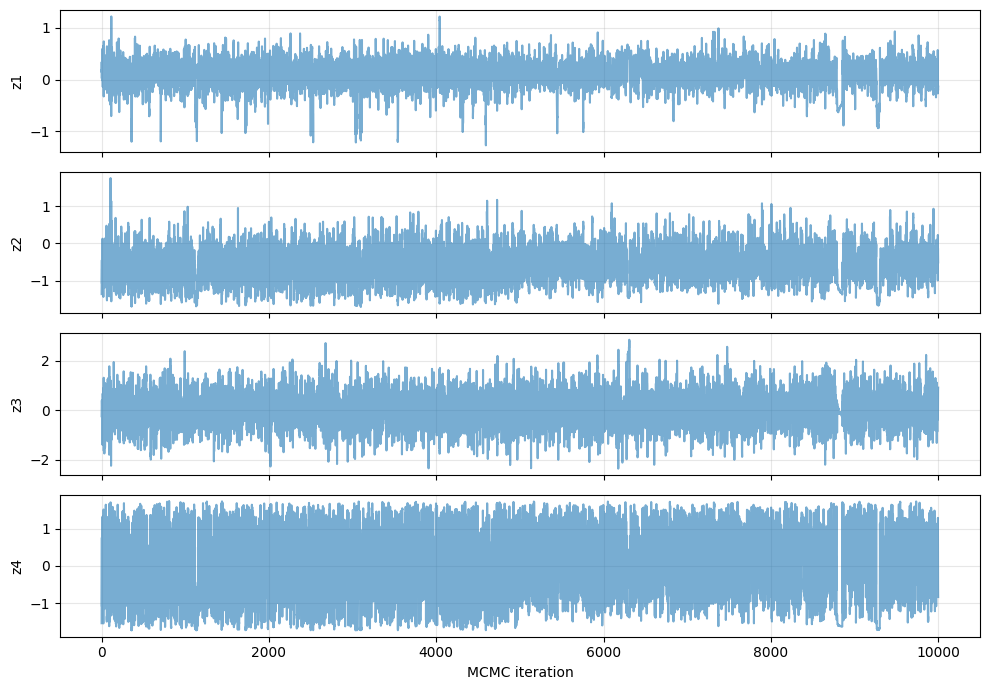

In [215]:
import matplotlib.pyplot as plt

def plot_traces(samples, names=("z1","z2","z3","z4")):
    fig, axes = plt.subplots(len(names), 1, figsize=(10, 7), sharex=True)
    for i, name in enumerate(names):
        axes[i].plot(samples[name], alpha=0.6)
        axes[i].set_ylabel(name)
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel("MCMC iteration")
    plt.tight_layout()
    plt.show()

plot_traces(samples)


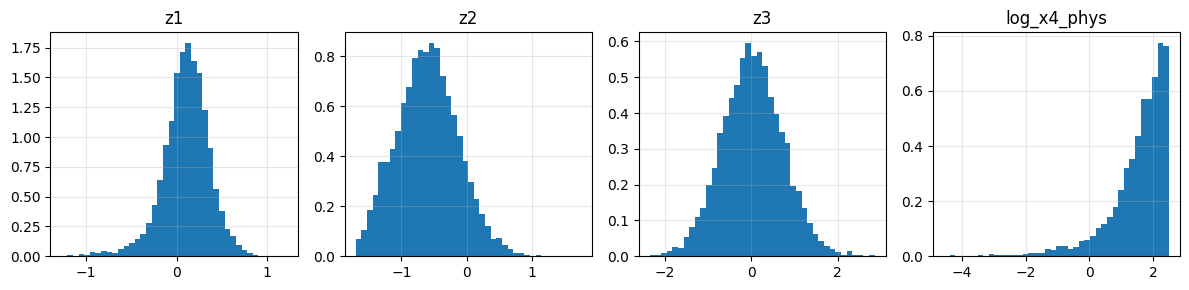

In [219]:
def plot_histograms(samples, names=("z1","z2","z3","z4")):
    fig, axes = plt.subplots(1, len(names), figsize=(12, 3))
    for ax, name in zip(axes, names):
        ax.hist(samples[name], bins=40, density=True)
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histograms(samples)

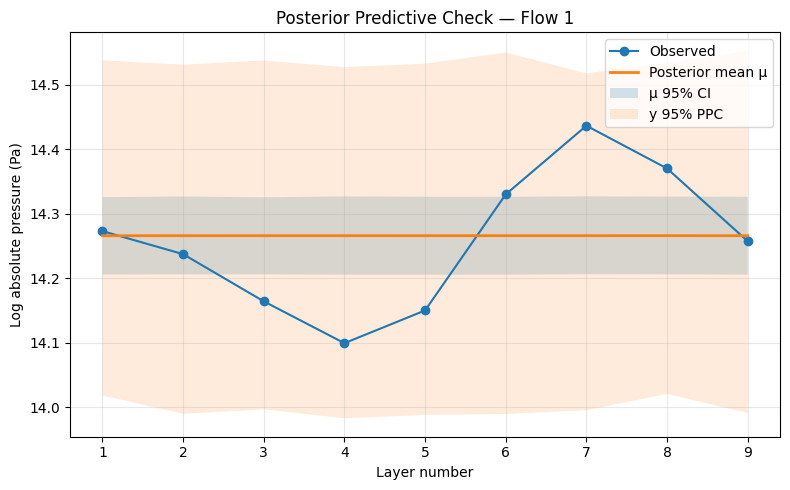

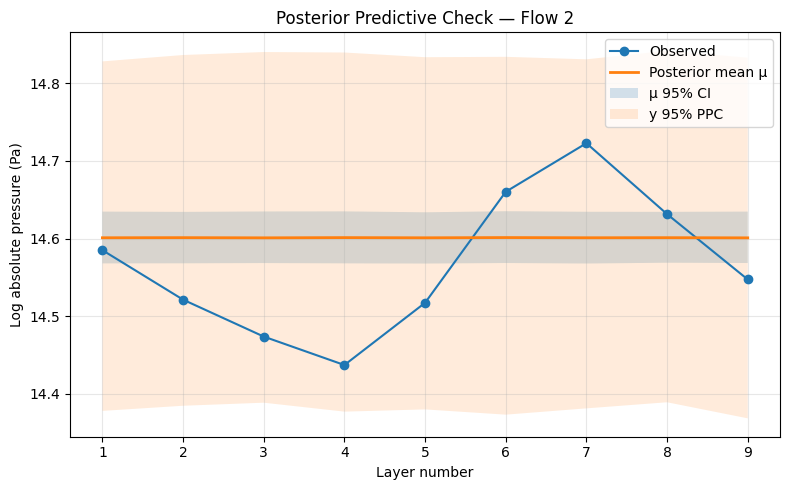

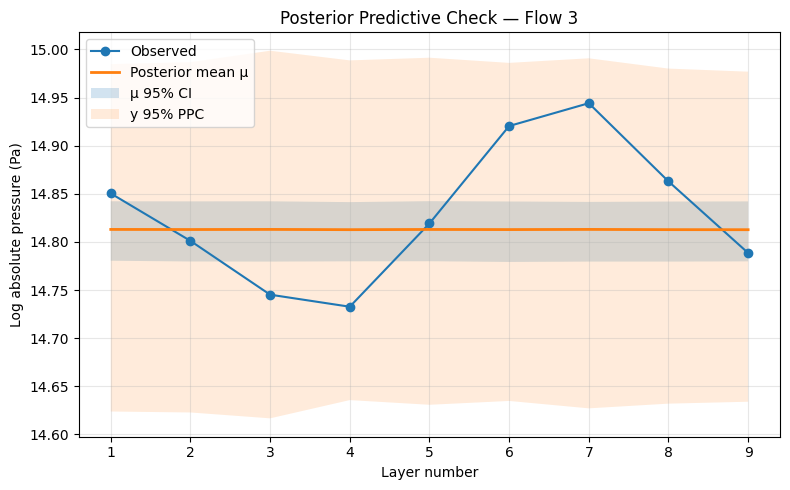

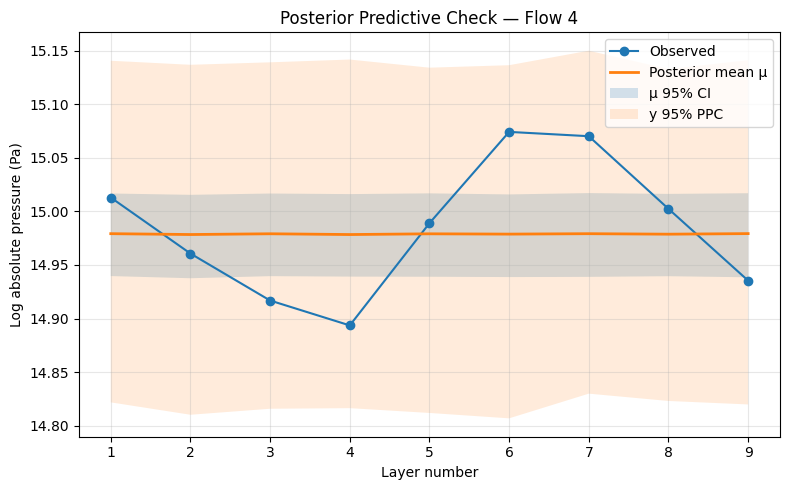

In [220]:
import numpy as np
import matplotlib.pyplot as plt

def posterior_predictive_summary(F, P_pa, layers, samples, gp_flow_maps,
                                 max_draws=2000, seed=0):
    """
    Returns summaries for each flow:
      mu_mean, mu_lo, mu_hi         : posterior over latent mean MU (no noise)
      y_mean,  y_lo,  y_hi          : posterior predictive over y (with sigma noise)
    Shapes: (N, K)
    """
    rng = np.random.default_rng(seed)

    F_np = np.asarray(F)
    y_obs = np.log(np.asarray(P_pa))          # (N, K)
    layers_np = np.asarray(layers)

    N, K = F_np.shape

    # Posterior draws
    z1 = np.asarray(samples["z1"])
    z2 = np.asarray(samples["z2"])
    z3 = np.asarray(samples["z3"])
    z4 = np.asarray(samples["z4"])
    sigma = np.asarray(samples["sigma"])      # (S, K)

    S = z1.shape[0]
    n_draws = min(S, max_draws)
    idx = rng.choice(S, size=n_draws, replace=False) if S > n_draws else np.arange(S)

    z1 = z1[idx]; z2 = z2[idx]; z3 = z3[idx]; z4 = z4[idx]
    sigma = sigma[idx, :]                     # (n_draws, K)

    # Compute MU draws: (n_draws, N, K)
    MU = np.empty((n_draws, N, K), dtype=float)
    for s in range(n_draws):
        for j in range(K):
            MU[s, :, j] = np.asarray(gp_flow_maps(z1[s], z2[s], z3[s], z4[s], F_np[:, j]))

    # Posterior predictive y draws: Normal(MU, sigma_flow)
    eps = rng.normal(size=(n_draws, N, K))
    Yrep = MU + eps * sigma[:, None, :]       # broadcast (n_draws,K)->(n_draws,N,K)

    # Summaries
    def q(a, p): return np.quantile(a, p, axis=0)

    mu_mean = MU.mean(axis=0)
    mu_lo   = q(MU, 0.025)
    mu_hi   = q(MU, 0.975)

    y_mean  = Yrep.mean(axis=0)
    y_lo    = q(Yrep, 0.025)
    y_hi    = q(Yrep, 0.975)

    return layers_np, y_obs, (mu_mean, mu_lo, mu_hi), (y_mean, y_lo, y_hi)


def plot_ppc_per_flow(layers, y_obs, mu_sum, y_sum, flow_names=None):
    """
    One plot per flow. All quantities are log(Pa).
    """
    mu_mean, mu_lo, mu_hi = mu_sum
    y_mean,  y_lo,  y_hi  = y_sum

    N, K = y_obs.shape
    if flow_names is None:
        flow_names = [f"Flow {j+1}" for j in range(K)]

    for j in range(K):
        plt.figure(figsize=(8, 5))

        # Observations
        plt.plot(layers, y_obs[:, j], "o-", label="Observed", linewidth=1.5)

        # Latent mean band (model uncertainty only)
        plt.plot(layers, mu_mean[:, j], "-", label="Posterior mean μ", linewidth=2)
        plt.fill_between(layers, mu_lo[:, j], mu_hi[:, j], alpha=0.20, label="μ 95% CI")

        # Posterior predictive band (includes noise sigma)
        plt.fill_between(layers, y_lo[:, j], y_hi[:, j], alpha=0.15, label="y 95% PPC")

        plt.xlabel("Layer number")
        plt.ylabel("Log absolute pressure (Pa)")
        plt.title(f"Posterior Predictive Check — {flow_names[j]}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# -------------------------
# Run it
# -------------------------
layers_used, y_obs, mu_sum, y_sum = posterior_predictive_summary(
    F=F[:L, :],
    P_pa=P_pa[:L, :],
    layers=layers[:L],
    samples=samples,
    gp_flow_maps=gp_flow_maps,
    max_draws=2000,
    seed=0
)

plot_ppc_per_flow(layers_used, y_obs, mu_sum, y_sum,
                  flow_names=[f"Flow {i+1}" for i in range(y_obs.shape[1])])


In [171]:
import jax.numpy as jnp
import numpy as np

# Posterior samples from MCMC
# samples = mcmc.get_samples()
z1s = jnp.asarray(samples["z1"])
z2s = jnp.asarray(samples["z2"])
z3s = jnp.asarray(samples["z3"])
z4s = jnp.asarray(samples["z4"])

# GP standardizer stats (these are for the GP INPUTS)
x_mean = jnp.asarray(gp_loaded.std.x_mean)  # shape (dim,)
x_std  = jnp.asarray(gp_loaded.std.x_std)   # shape (dim,)

# 1) un-standardize to the GP input scale (the scale used in the GP CSV)
x1_gp = z1s * x_std[0] + x_mean[0]
x2_gp = z2s * x_std[1] + x_mean[1]
x3_gp = z3s * x_std[2] + x_mean[2]
x4_gp = z4s * x_std[3] + x_mean[3]

# 2) invert your manual scaling to get physical parameters
x1_phys = x1_gp
x2_phys = x2_gp
x3_phys = 1.0   * x3_gp
x4_phys = 1.0   * x4_gp

def summarize(x, name):
    x = np.asarray(x)
    q2p5, q50, q97p5 = np.quantile(x, [0.025, 0.5, 0.975])
    mean = x.mean()
    print(f"{name:8s}  mean={mean: .4g}  median={q50: .4g}  95% CI=[{q2p5: .4g}, {q97p5: .4g}]")

summarize(x1_phys, "x1_phys")
summarize(x2_phys, "x2_phys")
summarize(x3_phys, "x3_phys")
summarize(x4_phys, "x4_phys")


x1_phys   mean= 0.6375  median= 0.6376  95% CI=[ 0.5637,  0.7105]
x2_phys   mean= 3801  median= 3721  95% CI=[ 2421,  5669]
x3_phys   mean= 5.11  median= 5.142  95% CI=[ 1.122,  9.117]
x4_phys   mean= 4.389  median= 4.392  95% CI=[ 3.032,  5.732]


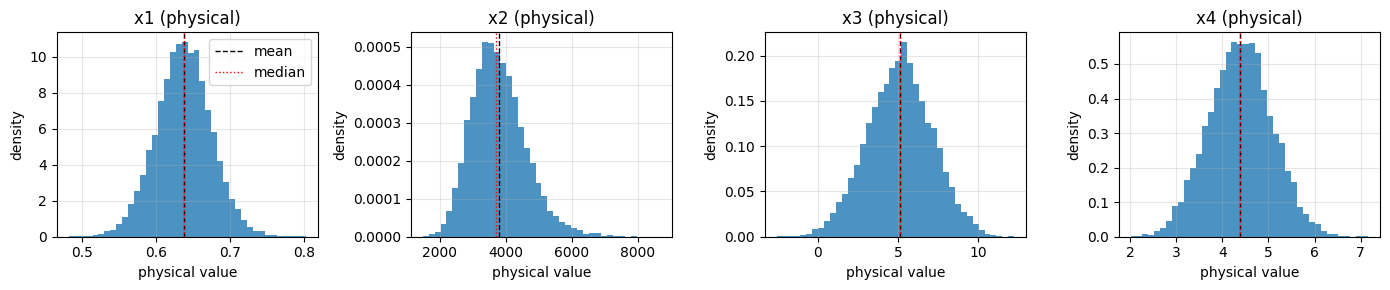

In [221]:
import matplotlib.pyplot as plt
import numpy as np

def plot_physical_histograms(x_list, names, bins=40):
    fig, axes = plt.subplots(1, len(x_list), figsize=(14, 3))

    for ax, x, name in zip(axes, x_list, names):
        x = np.asarray(x)
        ax.hist(x, bins=bins, density=True, alpha=0.8)
        ax.set_title(name)
        ax.set_xlabel("physical value")
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)

        # Mark mean and median
        ax.axvline(x.mean(), color="k", linestyle="--", linewidth=1, label="mean")
        ax.axvline(np.median(x), color="r", linestyle=":", linewidth=1, label="median")

    axes[0].legend()
    plt.tight_layout()
    plt.show()

plot_physical_histograms(
    [x1_phys, x2_phys, x3_phys, x4_phys],
    ["x1 (physical)", "x2 (physical)", "x3 (physical)", "x4 (physical)"]
)


In [173]:
import numpy as np

def sample_priors(prior_cfg, K=4, n=20000, seed=0):
    """
    prior_cfg: dict with keys:
      z: dict with mu/sd for z1..z4
      b: dict with mu/sd
      sigma: dict with scale (HalfNormal scale)
    Returns: dict of numpy arrays shaped like posterior samples
    """
    rng = np.random.default_rng(seed)

    # z priors
    z = prior_cfg["z"]
    out = {}
    for name in ["z1", "z2", "z3", "z4"]:
        mu = float(z[name]["mu"])
        sd = float(z[name]["sd"])
        out[name] = rng.normal(mu, sd, size=n)

    # # b ~ Normal(mu, sd) for each flow
    # b_mu = float(prior_cfg["b"]["mu"])
    # b_sd = float(prior_cfg["b"]["sd"])
    # out["b"] = rng.normal(b_mu, b_sd, size=(n, K))

    # sigma ~ HalfNormal(scale) for each flow
    # HalfNormal(scale): |N(0, scale^2)|
    sig_scale = float(prior_cfg["sigma"]["scale"])
    out["sigma"] = np.abs(rng.normal(0.0, sig_scale, size=(n, K)))

    return out


import matplotlib.pyplot as plt

def plot_prior_vs_posterior(mcmc_samples, prior_samples, K=4, bins=50):
    """
    mcmc_samples: dict from mcmc.get_samples()
    prior_samples: dict from sample_priors()
    """
    # ---- z1..z4 ----
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for ax, name in zip(axes, ["z1", "z2", "z3", "z4"]):
        post = np.asarray(mcmc_samples[name])
        prior = np.asarray(prior_samples[name])

        ax.hist(prior, bins=bins, density=True, alpha=0.45, label="prior")
        ax.hist(post,  bins=bins, density=True, alpha=0.55, label="posterior")
        ax.set_title(name)
        ax.grid(True, alpha=0.25)

    axes[0].legend()
    plt.tight_layout()
    plt.show()

    # # ---- b per flow ----
    # fig, axes = plt.subplots(1, K, figsize=(4*K, 3))
    # if K == 1:
    #     axes = [axes]
    # for j, ax in enumerate(axes):
    #     post = np.asarray(mcmc_samples["b"])[:, j]
    #     prior = np.asarray(prior_samples["b"])[:, j]

    #     ax.hist(prior, bins=bins, density=True, alpha=0.45, label="prior")
    #     ax.hist(post,  bins=bins, density=True, alpha=0.55, label="posterior")
    #     ax.set_title(f"b[{j}]")
    #     ax.grid(True, alpha=0.25)

    # axes[0].legend()
    # plt.tight_layout()
    # plt.show()

    # ---- sigma per flow ----
    fig, axes = plt.subplots(1, K, figsize=(4*K, 3))
    if K == 1:
        axes = [axes]
    for j, ax in enumerate(axes):
        post = np.asarray(mcmc_samples["sigma"])[:, j]
        prior = np.asarray(prior_samples["sigma"])[:, j]

        ax.hist(prior, bins=bins, density=True, alpha=0.45, label="prior")
        ax.hist(post,  bins=bins, density=True, alpha=0.55, label="posterior")
        ax.set_title(f"sigma[{j}]")
        ax.grid(True, alpha=0.25)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


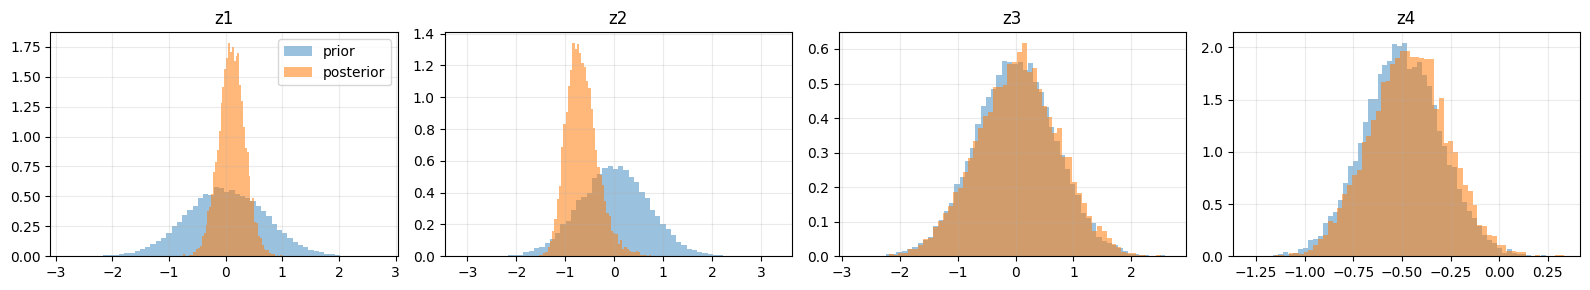

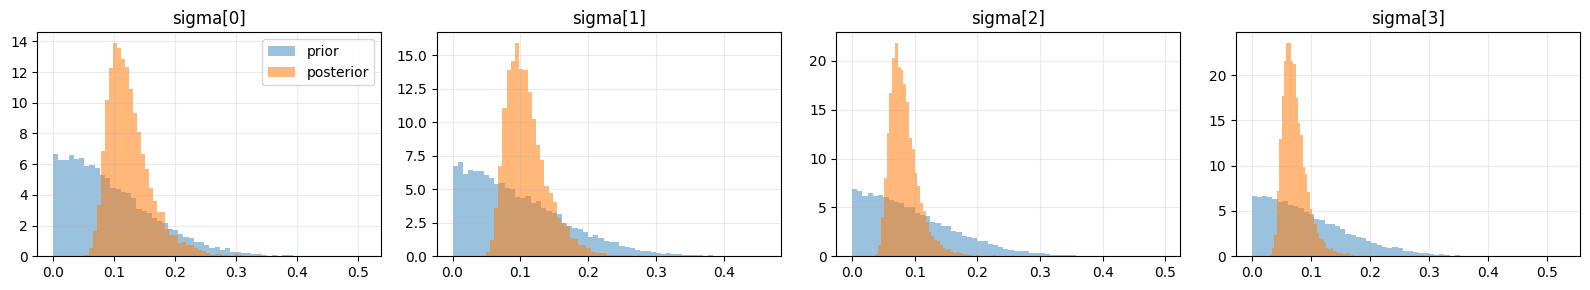

In [174]:
# posterior
post = mcmc.get_samples()

# prior config matching your model
prior_cfg = {
    "z": {
        "z1": {"mu": 0.0, "sd": 0.7},
        "z2": {"mu": 0.0, "sd": 0.7},
        "z3": {"mu": 0.0, "sd": 0.7},
        "z4": {"mu": -0.5, "sd": 0.2},
    },
    "sigma": {"scale": 0.12},
}

K = F.shape[1]  # should be 4
prior = sample_priors(prior_cfg, K=K, n=20000, seed=0)

plot_prior_vs_posterior(post, prior, K=K, bins=60)


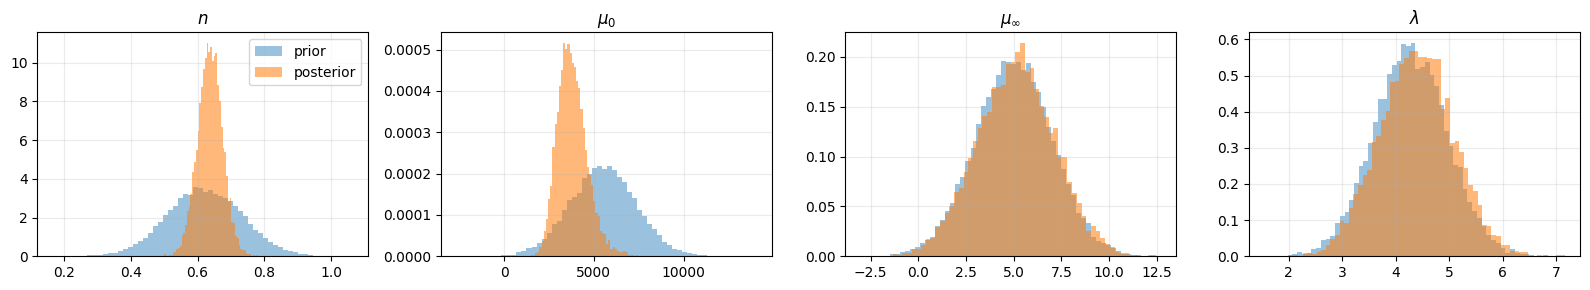

In [175]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Transform z -> GP scale -> physical
# -----------------------------
def z_to_phys(z1, z2, z3, z4, x_mean, x_std,
              phys_scale=None, phys_shift=None):
    """
    z* : arrays (n,)
    x_mean, x_std: arrays (4,)
    phys_scale / phys_shift: optional arrays (4,) for manual inverse scaling:
        x_phys = x_gp * phys_scale + phys_shift
    If you don't have extra manual scaling, leave them None.
    """

    # z -> GP input scale
    x1_gp = z1 * x_std[0] + x_mean[0]
    x2_gp = z2 * x_std[1] + x_mean[1]
    x3_gp = z3 * x_std[2] + x_mean[2]
    x4_gp = z4 * x_std[3] + x_mean[3]

    X_gp = np.stack([x1_gp, x2_gp, x3_gp, x4_gp], axis=-1)  # (n, 4)

    # GP scale -> physical (manual inverse scaling, if any)
    if phys_scale is None:
        phys_scale = np.ones(4)
    if phys_shift is None:
        phys_shift = np.zeros(4)

    X_phys = X_gp * np.asarray(phys_scale) + np.asarray(phys_shift)  # (n, 4)
    return X_phys


# -----------------------------
# 2) Plot helper
# -----------------------------
def plot_prior_vs_posterior_physical(post_samples, prior_samples, x_mean, x_std,
                                     phys_scale=None, phys_shift=None,
                                     bins=60, names=None):
    """
    post_samples/prior_samples: dicts containing z1..z4
    """

    # posterior -> phys
    Zp = post_samples
    Xp = z_to_phys(np.asarray(Zp["z1"]), np.asarray(Zp["z2"]),
                   np.asarray(Zp["z3"]), np.asarray(Zp["z4"]),
                   x_mean, x_std, phys_scale=phys_scale, phys_shift=phys_shift)

    # prior -> phys
    Zr = prior_samples
    Xr = z_to_phys(np.asarray(Zr["z1"]), np.asarray(Zr["z2"]),
                   np.asarray(Zr["z3"]), np.asarray(Zr["z4"]),
                   x_mean, x_std, phys_scale=phys_scale, phys_shift=phys_shift)

    if names is None:
        names = ["x1_phys", "x2_phys", "x3_phys", "x4_phys"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for i, ax in enumerate(axes):
        ax.hist(Xr[:, i], bins=bins, density=True, alpha=0.45, label="prior")
        ax.hist(Xp[:, i], bins=bins, density=True, alpha=0.55, label="posterior")
        ax.set_title(names[i])
        ax.grid(True, alpha=0.25)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) Use it with your objects
# -----------------------------

# posterior
post = mcmc.get_samples()

# prior
K = F.shape[1]
prior = sample_priors(prior_cfg, K=K, n=20000, seed=0)

# GP input standardizer stats
x_mean = np.asarray(gp_loaded.std.x_mean)  # (4,)
x_std  = np.asarray(gp_loaded.std.x_std)   # (4,)

# If you truly have NO extra manual scaling beyond what you showed (x3_phys=1*x3_gp etc.),
# then leave phys_scale/phys_shift as None.
# If you DO have manual inverse scaling, set them here, e.g.:
# phys_scale = np.array([s1, s2, s3, s4])
# phys_shift = np.array([c1, c2, c3, c4])
phys_scale = np.array([1.0, 1.0, 1.0, 1.0])
phys_shift = np.array([0.0, 0.0, 0.0, 0.0])

plot_prior_vs_posterior_physical(
    post_samples=post,
    prior_samples=prior,
    x_mean=x_mean,
    x_std=x_std,
    phys_scale=phys_scale,
    phys_shift=phys_shift,
    bins=60,
    names=["$n$", "$\mu_0$", "$\mu_{\infty}$", "$\lambda$"]
)


# -----------------------------
# 4) (Optional) b and sigma plots (no "physical" transform typically)
# -----------------------------
# def plot_b_sigma(post, prior, K, bins=60):
#     # b per flow
#     fig, axes = plt.subplots(1, K, figsize=(4*K, 3))
#     if K == 1:
#         axes = [axes]
#     for j, ax in enumerate(axes):
#         ax.hist(np.asarray(prior["b"])[:, j], bins=bins, density=True, alpha=0.45, label="prior")
#         ax.hist(np.asarray(post["b"])[:, j],  bins=bins, density=True, alpha=0.55, label="posterior")
#         ax.set_title(f"b[{j}]")
#         ax.grid(True, alpha=0.25)
#     axes[0].legend()
#     plt.tight_layout()
#     plt.show()

#     # sigma per flow
#     fig, axes = plt.subplots(1, K, figsize=(4*K, 3))
#     if K == 1:
#         axes = [axes]
#     for j, ax in enumerate(axes):
#         ax.hist(np.asarray(prior["sigma"])[:, j], bins=bins, density=True, alpha=0.45, label="prior")
#         ax.hist(np.asarray(post["sigma"])[:, j],  bins=bins, density=True, alpha=0.55, label="posterior")
#         ax.set_title(f"sigma[{j}]")
#         ax.grid(True, alpha=0.25)
#     axes[0].legend()
#     plt.tight_layout()
#     plt.show()

# plot_b_sigma(post, prior, K=K, bins=60)


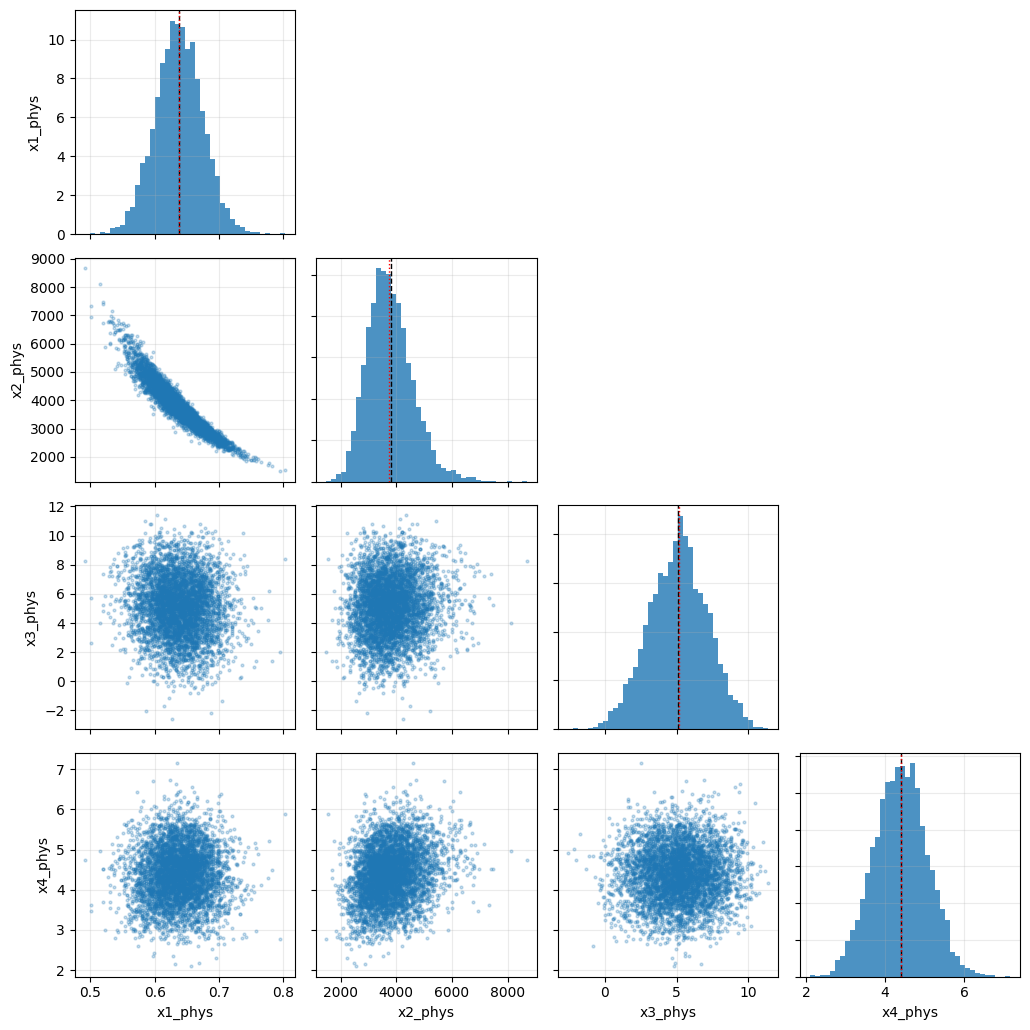

In [176]:
import numpy as np
import matplotlib.pyplot as plt

def corner_plot(samples_dict, names, max_points=5000, bins=40):
    """
    samples_dict: dict name -> 1D array of posterior samples (same length)
    names: list of keys in desired order
    """
    X = np.column_stack([np.asarray(samples_dict[n]) for n in names])
    S, D = X.shape

    # optional thinning for speed
    if S > max_points:
        idx = np.random.choice(S, size=max_points, replace=False)
        X = X[idx, :]
        S = max_points

    fig, axes = plt.subplots(D, D, figsize=(2.6*D, 2.6*D))

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i == j:
                ax.hist(X[:, j], bins=bins, density=True, alpha=0.8)
                ax.grid(True, alpha=0.25)

                # mean / median markers
                ax.axvline(X[:, j].mean(), color="k", linestyle="--", linewidth=1)
                ax.axvline(np.median(X[:, j]), color="r", linestyle=":", linewidth=1)

            elif i > j:
                ax.plot(X[:, j], X[:, i], "o", markersize=2, alpha=0.25)
                ax.grid(True, alpha=0.25)
            else:
                ax.axis("off")

            # Labels only on outer edges
            if i == D - 1 and j <= i:
                ax.set_xlabel(names[j])
            else:
                ax.set_xticklabels([])

            if j == 0 and i >= j:
                ax.set_ylabel(names[i])
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    plt.show()


# ---- call it (physical scale) ----
samples_phys = {
    "x1_phys": x1_phys,
    "x2_phys": x2_phys,
    "x3_phys": x3_phys,
    "x4_phys": x4_phys,
}

corner_plot(samples_phys, ["x1_phys", "x2_phys", "x3_phys", "x4_phys"])


In [177]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def corner_kde_overlay(
    posts,                      # dict: label -> samples_dict (each samples_dict: name -> 1D array)
    names,                      # ["x1_phys","x2_phys","x3_phys","x4_phys"]
    cmap_by_label=None,         # dict label -> "Blues"/"Reds"/"Greens"/...
    color_by_label=None,        # dict label -> "blue"/"red"/"green"/...
    max_points=6000,
    diag="kde",                 # "kde" or "hist"
    bins=40,
    levels=7,
    fill_alpha=0.22,
    line_width=1.3,
    thresh=0.05,
    figsize=None,
    axis_labels=None,           # dict name -> pretty label
    title=None
):
    """
    posts: {"Δ21": {"x1_phys":..., ...}, "Δ43": {...}, "ALL": {...}}
    """
    labels = list(posts.keys())
    D = len(names)

    if figsize is None:
        figsize = (2.6*D, 2.6*D)

    if cmap_by_label is None:
        cmap_by_label = {lab: "Blues" for lab in labels}
    if color_by_label is None:
        color_by_label = {lab: "blue" for lab in labels}
    if axis_labels is None:
        axis_labels = {n: n for n in names}

    # Build thinned matrices per posterior
    X_by_label = {}
    for lab in labels:
        X = np.column_stack([np.asarray(posts[lab][n]).ravel() for n in names])
        S = X.shape[0]
        if S > max_points:
            idx = np.random.choice(S, size=max_points, replace=False)
            X = X[idx, :]
        X_by_label[lab] = X

    fig, axes = plt.subplots(D, D, figsize=figsize)

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            if i == j:
                # diagonal: 1D density overlay
                for lab in labels:
                    x = X_by_label[lab][:, j]
                    if diag == "kde":
                        sns.kdeplot(x=x, ax=ax, color=color_by_label[lab], linewidth=line_width, fill=False)
                    else:
                        ax.hist(x, bins=bins, density=True, alpha=0.25, color=color_by_label[lab])
                ax.grid(True, alpha=0.25)

            else:
                # lower triangle: 2D KDE overlay (filled + outline), like your example
                for lab in labels:
                    x = X_by_label[lab][:, j]
                    y = X_by_label[lab][:, i]

                    sns.kdeplot(
                        x=x, y=y, ax=ax,
                        cmap=cmap_by_label[lab],
                        levels=levels, fill=True,
                        alpha=fill_alpha, thresh=thresh
                    )
                    sns.kdeplot(
                        x=x, y=y, ax=ax,
                        color=color_by_label[lab],
                        levels=levels, fill=False,
                        linewidths=line_width,
                        label=f"{lab}" if (i == 1 and j == 0) else None  # add legend once
                    )

                ax.grid(True, alpha=0.25)

            # Outer labels only
            if i == D - 1:
                ax.set_xlabel(axis_labels[names[j]])
            else:
                ax.set_xlabel("")
                ax.set_xticklabels([])

            if j == 0 and i > 0:
                ax.set_ylabel(axis_labels[names[i]])
            else:
                ax.set_ylabel("")
                ax.set_yticklabels([])

    # Legend (pulled from the one panel we labeled)
    handles, leg_labels = axes[1,0].get_legend_handles_labels() if D > 1 else axes[0,0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, leg_labels, loc="upper right", frameon=True)

    if title:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()


In [178]:
samples_phys = {
    "x1_phys": np.asarray(x1_phys),
    "x2_phys": np.asarray(x2_phys),
    "x3_phys": np.asarray(x3_phys),
    "x4_phys": np.asarray(x4_phys),
}

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

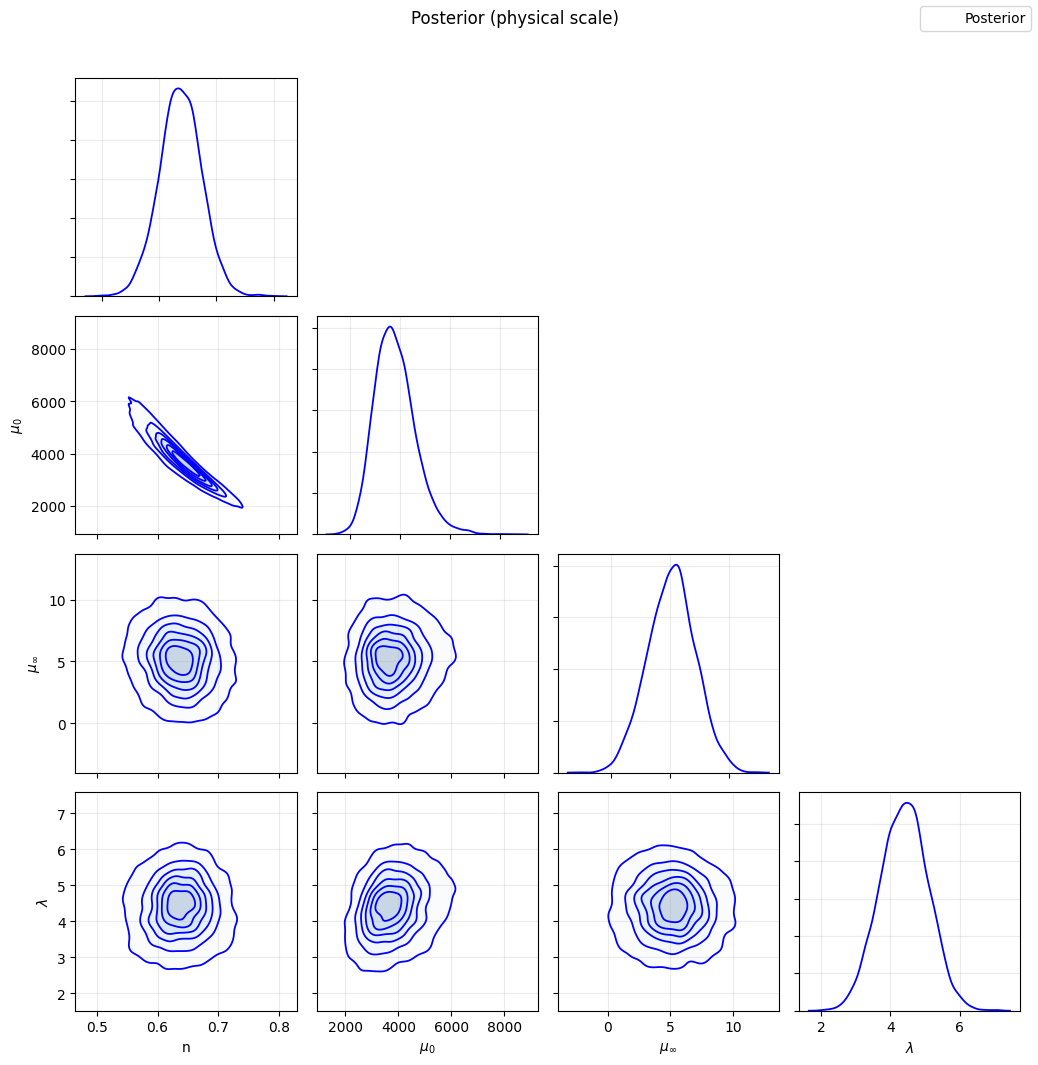

In [180]:
posts = {
    "Posterior": samples_phys
}

corner_kde_overlay(
    posts,
    names=["x1_phys","x2_phys","x3_phys","x4_phys"],
    cmap_by_label={"Posterior":"Blues"},
    color_by_label={"Posterior":"blue"},
    axis_labels={
        "x1_phys":"n",
        "x2_phys":"$\mu_0$",
        "x3_phys":"$\mu_{\infty}$",
        "x4_phys":"$\lambda$",
    },
    title="Posterior (physical scale)"
)

# -----------------------

In [257]:
import numpy as np
import jax.numpy as jnp

def dmu_dz4_vs_flow(gp_flow_maps, z1, z2, z3, z4, flows, eps=0.05):
    flows = np.asarray(flows)
    out = []
    for f in flows:
        mu_p = gp_flow_maps(z1, z2, z3, z4 + eps, jnp.array([f]))[0]
        mu_m = gp_flow_maps(z1, z2, z3, z4 - eps, jnp.array([f]))[0]
        out.append((mu_p - mu_m) / (2 * eps))
    return np.asarray(out)

# pick a representative point (posterior mean is good)
z1m = float(np.mean(np.asarray(samples["z1"])))
z2m = float(np.mean(np.asarray(samples["z2"])))
z3m = float(np.mean(np.asarray(samples["z3"])))
z4m = float(np.mean(np.asarray(samples["z4"])))

# your 4 flow values (use actual raw flow values)
flows4 = np.asarray(F[0, :])   # if each row has the same 4 flows; else pick a representative row

sens = dmu_dz4_vs_flow(gp_flow_maps, z1m, z2m, z3m, z4m, flows4, eps=0.05)

print("flows:", flows4)
print("d mu / d z4:", sens)


flows: [2.9362721e-07 4.8930025e-07 6.8509365e-07 8.8121266e-07]
d mu / d z4: [-0.31920433 -0.2967167  -0.25455475 -0.34685135]


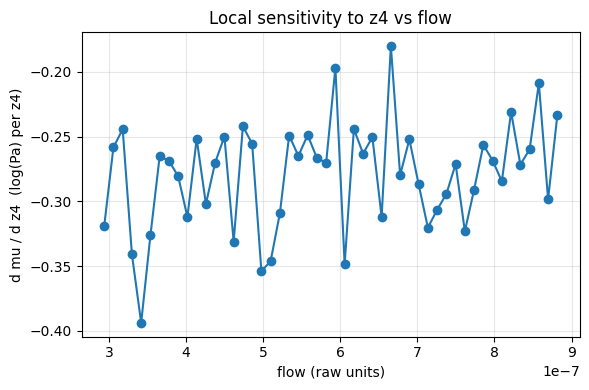

In [258]:
import matplotlib.pyplot as plt

flow_grid = np.linspace(np.min(F), np.max(F), 50)
sens_grid = dmu_dz4_vs_flow(gp_flow_maps, z1m, z2m, z3m, z4m, flow_grid, eps=0.05)

plt.figure(figsize=(6,4))
plt.plot(flow_grid, sens_grid, marker="o", linewidth=1.5)
plt.xlabel("flow (raw units)")
plt.ylabel("d mu / d z4  (log(Pa) per z4)")
plt.title("Local sensitivity to z4 vs flow")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [158]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from numpyro.infer import Predictive

PA_TO_PSI = 1.0 / 6894.76

def plot_posterior_predictive_vs_layer(
    mcmc, F, y_log_pa, layer_idx=None,   # layer_idx only needed for x-axis labels
    model_fn=None,
    plot_in="psi",        # "psi" or "pa"
    ci=0.95,              # credible interval
    n_post_draws=1000,    # thin posterior draws for speed
):
    """
    F: (N,K) flows
    y_log_pa: (N,K) observed log(Pa)
    """
    assert model_fn is not None, "Pass model_fn=model_calibrate_abslog_multiflow_constbias_perflow"

    posterior = mcmc.get_samples()

    # thin posterior to n_post_draws for speed
    S = len(next(iter(posterior.values())))
    if S > n_post_draws:
        idx = np.random.choice(S, size=n_post_draws, replace=False)
        posterior_thin = {k: np.asarray(v)[idx] for k, v in posterior.items()}
    else:
        posterior_thin = {k: np.asarray(v) for k, v in posterior.items()}

    # Posterior predictive
    pred = Predictive(model_fn, posterior_samples=posterior_thin, return_sites=["y"])
    out = pred(jax.random.PRNGKey(0), F=F, y_log_pa=None)  # y_log_pa=None -> generate
    y_draws_logpa = np.asarray(out["y"])  # (S, N, K)

    # Convert to pressure units if desired
    if plot_in.lower() == "psi":
        y_draws = np.exp(y_draws_logpa) * PA_TO_PSI
        y_obs = np.exp(np.asarray(y_log_pa)) * PA_TO_PSI
        ylabel = "Absolute Pressure (PSI)"
    else:
        y_draws = np.exp(y_draws_logpa)
        y_obs = np.exp(np.asarray(y_log_pa))
        ylabel = "Absolute Pressure (Pa)"

    # Summaries
    mean = y_draws.mean(axis=0)  # (N,K)
    alpha = (1.0 - ci) / 2.0
    lo = np.quantile(y_draws, alpha, axis=0)
    hi = np.quantile(y_draws, 1.0 - alpha, axis=0)

    N, K = mean.shape
    x = np.arange(1, N+1) if layer_idx is None else np.asarray(layer_idx)

    # Plot
    plt.figure(figsize=(10, 5))
    for j in range(K):
        plt.plot(x, mean[:, j], marker="o", linewidth=2, label=f"Flow {j+1}")
        plt.fill_between(x, lo[:, j], hi[:, j], alpha=0.2)

        # optional: overlay observations
        plt.plot(x, y_obs[:, j], linestyle="--", linewidth=1, alpha=0.7)

    plt.xlabel("Layer")
    plt.ylabel(ylabel)
    plt.title(f"Posterior Predictive Mean and {int(ci*100)}% CI vs Layer")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [159]:
plot_posterior_predictive_vs_layer(
    mcmc=mcmc,
    F=F,                      # (9,4)
    y_log_pa=y_log_pa,        # (9,4) observed log(Pa)
    layer_idx=np.arange(1, 10),
    model_fn=model_calibrate_abslog_multiflow_constbias_perflow,
    plot_in="psi",
    ci=0.95,
    n_post_draws=800,
)


NameError: name 'y_log_pa' is not defined

In [306]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp

def model_calibrate_abslog_multiflow_diffadj_perflow_corr(F, y_log_pa):
    N, K = F.shape
    assert K == 4

    z1 = numpyro.sample("z1", dist.Normal(0.0, 0.7))
    z2 = numpyro.sample("z2", dist.Normal(0.0, 0.7))
    z3 = numpyro.sample("z3", dist.Normal(0.0, 0.7))
    z4 = numpyro.sample("z4", dist.Normal(-0.5, 0.5))

    MU = jnp.stack([gp_flow_maps(z1, z2, z3, z4, F[:, j]) for j in range(K)], axis=1)  # (N,4)

    b = numpyro.sample("b", dist.Normal(0.0, 0.02).expand([K]))  # (4,)
    MU_b = MU + b[None, :]

    mu_diff = MU_b[:, 1:] - MU_b[:, :-1]          # (N,3)
    y_diff  = y_log_pa[:, 1:] - y_log_pa[:, :-1]  # (N,3)

    # per-flow noise in original space
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.15).expand([K]))  # (4,)

    s1, s2, s3, s4 = sigma
    S = jnp.array([
        [s2**2 + s1**2,   -s2**2,         0.0],
        [-s2**2,          s3**2 + s2**2,  -s3**2],
        [0.0,             -s3**2,         s4**2 + s3**2],
    ])

    numpyro.sample("y", dist.MultivariateNormal(loc=mu_diff, covariance_matrix=S), obs=y_diff)


In [307]:
from numpyro.infer import MCMC, NUTS, init_to_median
import jax.random as jr
import jax.numpy as jnp

def run_nuts_calibration_abslog_adjdiff(
    F, P_pa,
    seed=111, warmup=300, samples=2000, chains=2,
    target_accept=0.75, max_tree_depth=10,
):
    y_log_pa = jnp.log(P_pa)

    kernel = NUTS(
        model_calibrate_abslog_multiflow_diffadj_perflow_corr,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
        dense_mass=False,
    )

    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",
        progress_bar=True,
    )

    key = jr.PRNGKey(seed)
    mcmc.run(key, F, y_log_pa)

    mcmc.print_summary()
    return mcmc

# Call it
mcmc = run_nuts_calibration_abslog_adjdiff(F[:L, :], P_pa[:L, :])
samples = mcmc.get_samples()

warmup:   4%|██▎                                                      | 91/2300 [00:39<15:51,  2.32it/s, 1023 steps of size 1.50e-05. acc. prob=0.67]


KeyboardInterrupt: 